In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

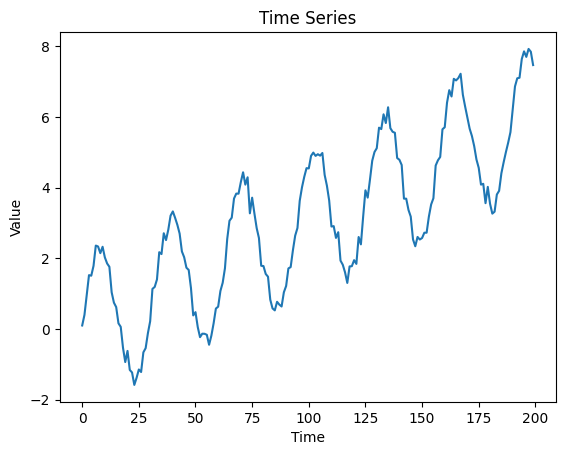

In [2]:
# =========================================================
# 1. Create time-series data
# =========================================================

np.random.seed(42)
torch.manual_seed(42)

# Example: trend + seasonality + noise
t = np.arange(0, 200)

data = (
    0.03 * t
    + 2 * np.sin(0.2 * t)
    + np.random.normal(0, 0.2, len(t))
)

plt.plot(t, data)
plt.title("Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()



In [3]:
# =========================================================
# 2. Normalize the data
# =========================================================

mean = data.mean()
std = data.std()

data_scaled = (data - mean) / std


In [4]:
# =========================================================
# 3. Convert time series into sequences
# =========================================================

sequence_length = 10

X = []
y = []

for i in range(len(data_scaled) - sequence_length):

    # Previous 10 observations
    X.append(
        data_scaled[i:i + sequence_length]
    )

    # Next observation
    y.append(
        data_scaled[i + sequence_length]
    )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (190, 10)
y shape: (190,)


In [5]:
# =========================================================
# 4. Train/test split
# =========================================================

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


# Convert to PyTorch tensors
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
).unsqueeze(-1)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
).unsqueeze(-1)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
).unsqueeze(-1)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
).unsqueeze(-1)

print("RNN input shape:", X_train.shape)



RNN input shape: torch.Size([152, 10, 1])


In [6]:
# =========================================================
# 5. Build the RNN model
# =========================================================

class TimeSeriesRNN(nn.Module):

    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        # RNN output:
        # batch x sequence x hidden_size
        output, hidden = self.rnn(x)

        # Get hidden representation
        # from final timestep
        final_output = output[:, -1, :]

        # Convert hidden state to forecast
        prediction = self.fc(final_output)

        return prediction


model = TimeSeriesRNN()

print(model)

TimeSeriesRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [7]:
# =========================================================
# 6. Loss function and optimizer
# =========================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)


In [8]:
# =========================================================
# 7. Train the model
# =========================================================

epochs = 500

for epoch in range(epochs):

    model.train()

    # Forward pass
    predictions = model(X_train)

    loss = criterion(
        predictions,
        y_train
    )

    # Backpropagation
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Loss: {loss.item():.6f}"
        )



Epoch 50/500, Loss: 0.020241
Epoch 100/500, Loss: 0.017966
Epoch 150/500, Loss: 0.016818
Epoch 200/500, Loss: 0.015595
Epoch 250/500, Loss: 0.014686
Epoch 300/500, Loss: 0.014523
Epoch 350/500, Loss: 0.014665
Epoch 400/500, Loss: 0.012439
Epoch 450/500, Loss: 0.011614
Epoch 500/500, Loss: 0.010222


In [9]:
# =========================================================
# 8. Make predictions
# =========================================================

model.eval()

with torch.no_grad():

    predictions = model(X_test)

predictions = (
    predictions
    .squeeze()
    .numpy()
)

actual = (
    y_test
    .squeeze()
    .numpy()
)


# Undo normalization
predictions = predictions * std + mean
actual = actual * std + mean


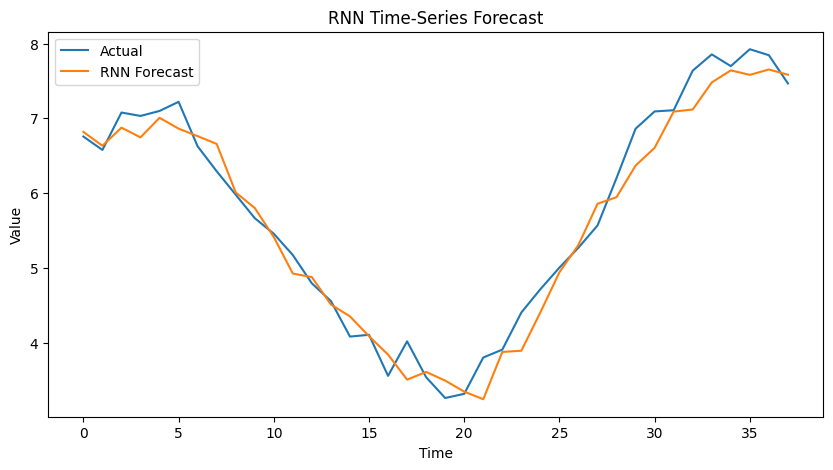

In [10]:
# =========================================================
# 9. Plot actual vs predicted
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="RNN Forecast"
)

plt.title("RNN Time-Series Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()

plt.show()



In [11]:
# =========================================================
# 10. Predict future values
# =========================================================

future_steps = 20

# Start with the final known sequence
current_sequence = data_scaled[-sequence_length:].copy()

future_predictions = []

model.eval()

for _ in range(future_steps):

    sequence_tensor = torch.tensor(
        current_sequence,
        dtype=torch.float32
    ).reshape(1, sequence_length, 1)

    with torch.no_grad():

        next_prediction = model(
            sequence_tensor
        ).item()

    future_predictions.append(
        next_prediction
    )

    # Remove oldest observation
    # and add new prediction
    current_sequence = np.append(
        current_sequence[1:],
        next_prediction
    )


# Undo normalization
future_predictions = (
    np.array(future_predictions) * std + mean
)

print("\nFuture predictions:")
print(future_predictions)



Future predictions:
[7.34040362 7.25420266 7.06184897 6.72587647 6.55242276 6.36096348
 6.07840574 5.92351653 5.76704897 5.55770727 5.38541736 5.28091836
 5.18125224 5.02956992 4.9385102  4.85295749 4.71826224 4.61492346
 4.51915919 4.39071487]


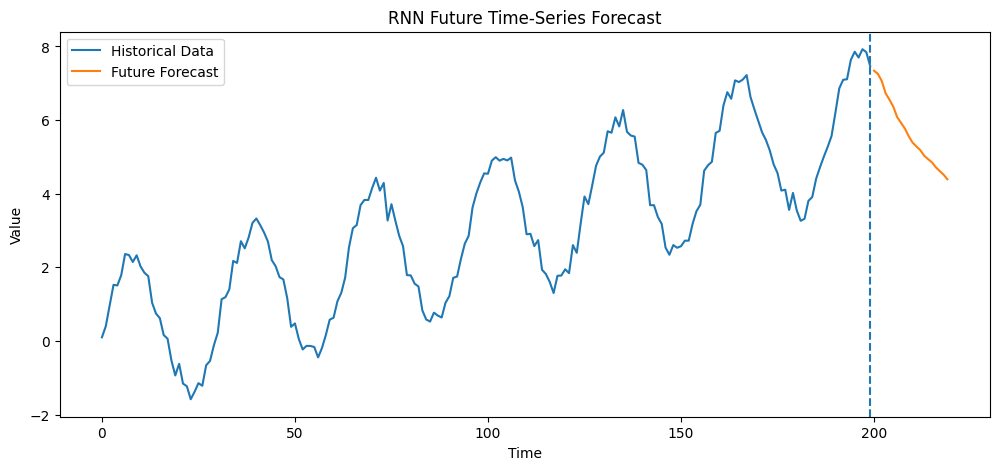

In [12]:
# =========================================================
# 11. Plot future forecast
# =========================================================

future_time = np.arange(
    len(data),
    len(data) + future_steps
)

plt.figure(figsize=(12, 5))

plt.plot(
    np.arange(len(data)),
    data,
    label="Historical Data"
)

plt.plot(
    future_time,
    future_predictions,
    label="Future Forecast"
)

plt.axvline(
    x=len(data) - 1,
    linestyle="--"
)

plt.title("RNN Future Time-Series Forecast")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()

plt.show()